1.LOAD DATASET

In [22]:
import pandas as pd

PLATFORM = "Instagram"

train_df = pd.read_csv(
    "../data_preprocess/processed_data/ml_data/instagram_train.csv"
)

test_df = pd.read_csv(
    "../data_preprocess/processed_data/ml_data/instagram_test.csv"
)

print(train_df.shape)
print(test_df.shape)

(24156, 56)
(6039, 56)


In [23]:
print("\n" + "="*30)
print("TRAIN CLASS DISTRIBUTION")
print("="*30)
print(train_df["popularity"].value_counts())
print("\nProportion %:")
print(train_df["popularity"].value_counts(normalize=True) * 100)

print("\n" + "="*30)
print("TEST CLASS DISTRIBUTION")
print("="*30)
print(test_df["popularity"].value_counts())
print("\nProportion %:")
print(test_df["popularity"].value_counts(normalize=True) * 100)


TRAIN CLASS DISTRIBUTION
popularity
0    19313
1     4843
Name: count, dtype: int64

Proportion %:
popularity
0    79.951151
1    20.048849
Name: proportion, dtype: float64

TEST CLASS DISTRIBUTION
popularity
0    4828
1    1211
Name: count, dtype: int64

Proportion %:
popularity
0    79.947011
1    20.052989
Name: proportion, dtype: float64


In [24]:
negative_count = train_df["popularity"].value_counts()[0]
positive_count = train_df["popularity"].value_counts()[1]
ratio = negative_count / positive_count
print(f"scale_pos_weight = {ratio:.2f}")

scale_pos_weight = 3.99


In [25]:
X_train = train_df.drop(
    columns=[
        "post_id",
        "user_id",
        "popularity"
    ]
)
y_train = train_df["popularity"]

X_test = test_df.drop(
    columns=[
        "post_id",
        "user_id",
        "popularity"
    ]
)
y_test = test_df["popularity"]

In [ ]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,     
    n_estimators=500,           
    learning_rate=0.02,         
    max_depth=6,                
    min_child_weight=1,         
    gamma=0.1,                  
    subsample=0.8,              
    colsample_bytree=0.5,       
    random_state=42,            
    n_jobs=-1                   
)

In [90]:
print("TRAINING XGBOOST...")

model.fit(
    X_train,
    y_train
)

TRAINING XGBOOST...


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [91]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]


In [92]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [93]:
print("CLASSIFICATION REPORT")
print(
    classification_report(
        y_test,
        y_pred
    )
)
print(f"ROC-AUC  : {roc_auc:.4f}")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.93      0.80      0.86      4828
           1       0.48      0.75      0.58      1211

    accuracy                           0.79      6039
   macro avg       0.70      0.77      0.72      6039
weighted avg       0.84      0.79      0.80      6039

ROC-AUC  : 0.8677


In [94]:
cm = confusion_matrix(
    y_test,
    y_pred
)
print("CONFUSION MATRIX")
print(cm)

CONFUSION MATRIX
[[3839  989]
 [ 303  908]]


In [ ]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 15 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(15)
)


TOP 15 IMPORTANT FEATURES
                   feature  importance
3                followers    0.203471
5                 verified    0.110643
33            topic_Travel    0.016785
24           topic_Fashion    0.016486
51  location_South America    0.016341
42        language_Spanish    0.015805
10          toxicity_score    0.015716
9       sentiment_negative    0.015230
8       sentiment_positive    0.014862
41     language_Portuguese    0.014768
18     sentiment_intensity    0.014555
4         account_age_days    0.014550
50        location_Oceania    0.014473
2               is_weekend    0.014456
23     topic_Entertainment    0.014389


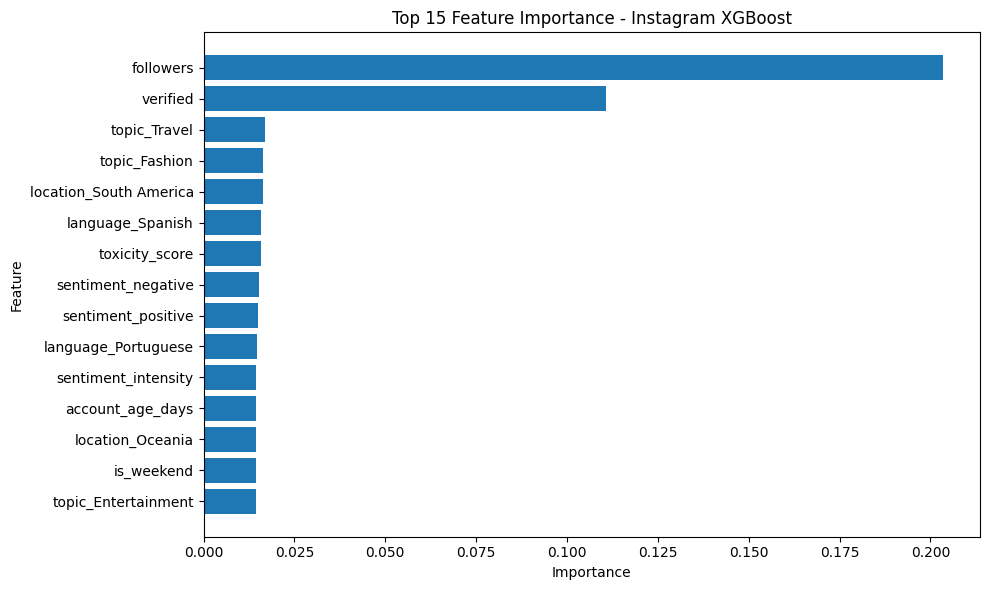

In [28]:
import matplotlib.pyplot as plt
top_n = 15

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 15 Feature Importance - Instagram XGBoost"
)

plt.tight_layout()

plt.show()